<a href="https://colab.research.google.com/github/shivanijawale185-hub/Handwritten-Digit-Recognition-MNIST/blob/main/Handwritten_Img_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train=x_train.reshape(-1,28,28,1).astype("float32")/255.0
x_test=x_test.reshape(-1,28,28,1).astype("float32")/255.0

In [4]:
model=models.Sequential([
    layers.Conv2D(32,(3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [6]:
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9600 - loss: 0.1284 - val_accuracy: 0.9857 - val_loss: 0.0423
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9864 - loss: 0.0430 - val_accuracy: 0.9887 - val_loss: 0.0367
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9882 - val_loss: 0.0355
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9932 - loss: 0.0215 - val_accuracy: 0.9874 - val_loss: 0.0368
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9875 - val_loss: 0.0437


In [7]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9875 - loss: 0.0437
Test Accuracy: 0.9875


In [8]:
import cv2

In [20]:
img_path = r"C:\Users\ASUS\OneDrive\Desktop\eight.jpg"

In [21]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [25]:
import cv2

img_path = r"C:\Users\ASUS\OneDrive\Desktop\eight.jpg"

print("Path:", img_path)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print("Image:", img)

Path: C:\Users\ASUS\OneDrive\Desktop\eight.jpg
Image: None


In [27]:
img_path = r"/content/eight.jpg"


In [28]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [29]:
img = cv2.resize(img, (28, 28))

In [30]:
img = cv2.bitwise_not(img)

In [31]:
img = img.astype("float32") / 255.0
img = img.reshape(1, 28, 28, 1)

In [32]:
pred = model.predict(img)
digit = np.argmax(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


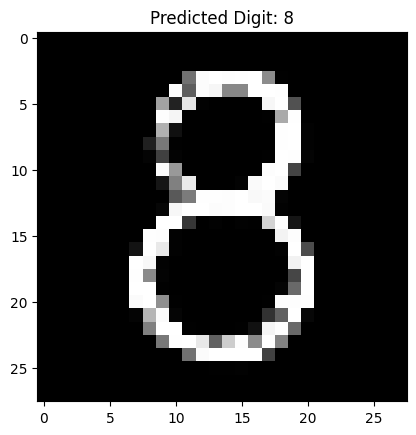

In [37]:
plt.imshow(img.reshape(28,28), cmap="gray")
plt.title(f"Predicted Digit: {digit}")
plt.show()

In [38]:
print("Predicted Digit:", digit)

Predicted Digit: 8
